# AdaLQO: Adaptive Learned Query Optimizer with Shifting Detector

In [1]:
import argparse
import time
import os
import copy

from config import Config
import numpy as np
import pandas as pd
import torch
import sys
import AdaLQO.utils as utils
from AdaLQO.utils import plot_res, pred_single_query
from AdaLQO.shift_detector import mmd, ws, ks_values_pca
import AdaLQO.replay_buffer as re_buf
import AdaLQO.shift_detector as det
from AdaLQO.utils import sle
import AdaLQO.dist_scores as dist_scores

sys.path.insert(0, 'bao_server')
import bao_server.model as bao_model

logger = Config.setup_logging()


In [2]:
df = pd.read_pickle("dataset/tpc-ds/data_df.pkl")
# BATCH_SIZE = 100
# data = utils.split_dataset(df, batch_size=BATCH_SIZE, random_state=None)

In [3]:
filtered_df = df[df['latency_list'].map(len) == 13]
print(filtered_df.shape)
# filtered_data = utils.split_dataset(filtered_df, batch_size=BATCH_SIZE, random_state=None)

(8201, 8)


In [4]:
cl_data_idx_df = pd.read_pickle("dataset/tpc-ds/data_X_test_t1.1_test0.4.pkl")
cl_data_idx = cl_data_idx_df['query_id']
cl_df = df[df["query_id"].isin(cl_data_idx)].copy()

In [5]:
cl_df = cl_df.drop_duplicates(subset=['query_id'])

In [6]:
cl_df.shape

(3241, 8)

## Init Bao Model


In [7]:
def train_bao_model(X, y):
    model = bao_model.BaoRegression(have_cache_data=False, verbose=False)
    model.fit_feature_extractor(X, y)
    idx_list, current_losses, replay_idx_list, replay_losses_list = model.fit_model(X, y, seed=42, ada_size=False)

    return model, idx_list, current_losses, replay_idx_list, replay_losses_list

def init_bao_model(train_data):
    X, y = utils.get_training_data(train_data)
    return train_bao_model(X, y)

train_data = filtered_df[:100]
reg_ori, idx_l, cur_losses, re_idx_l, re_losses_l = init_bao_model(train_data)

In [8]:
# reg.save("models/tpcds_bao_ori")

In [1]:
import joblib
# Load initial Bao Model
# loaded_reg_ori = bao_model.BaoRegression(have_cache_data=False, verbose=False)
# bao.load("models/tpcds_bao_ori")

# Load regret classifier
package = joblib.load("models/classifier_best_model.pkl")
classifier = package["model"]
features = package["feature_names"]

### Classifier prediction sample

In [2]:
# Prepare new data
X_new = cl_data_idx_df[features]
X_new = X_new.drop("query_id", axis=1)
# Predict
y_pred = classifier.predict(X_new)
# Probability
y_prob = classifier.predict_proba(X_new)[:, 1]

NameError: name 'cl_data_idx_df' is not defined

## 3. Queries(Plans) Featurization sample

In [11]:
# row = filtered_data[0][2].loc[225]
# query_plans = row["plans"]
# query_embeddings = det.embedding_single_query(reg, query_plans)
# print(query_embeddings.shape)

## 4. Predict Other Group Data & Continual Learning

In [12]:
import bao_server.featurize as f

def safe_prediction(model, data):
    try:
        return utils.pred_many(model, data)
    except f.TreeBuilderError as e:
        print("TreeBuilderError during prediction:", e)
        print("Refitting feature extractor and model on current batch...")

        X = []
        y = []

        for _, row in data.iterrows():
            X.extend(row["plans"])
            y.extend(row["latency_list"])

        model.fit_feature_extractor(X, y)
        model.fit_model(X, y, seed=42, ada_size=False)

        return utils.pred_many(model, data)

#### Regrest vs Query

In [13]:
# reg_ori = loaded_reg_ori
ori_res_list = []
for index, row in cl_df.iterrows():
    res = pred_single_query(reg_ori, row)
    ori_res_list.append(res)
# res

## 4. CL algorithm

In [14]:
buffer = 'rs'
buffer_size=5000
concentration=0.1
latest_buffer = []
if buffer == 'lwp':
    handler_buffer = re_buf.summarizer(buffer_limit=buffer_size, loss_ada=True,
                                concentration=concentration,
                                is_move=False)
else:
    handler_buffer = re_buf.summarizer(buffer_limit=buffer_size, loss_ada=False,
                                concentration=concentration,
                                is_move=False)


In [15]:
replay_list = []
replay_queries_tmp, _ = handler_buffer.get_all_samples()
for (_, y_i, plan, _, _) in replay_queries_tmp:
	replay_list.append((plan, y_i))

# predict the current query
res = pred_single_query(reg_ori, cl_df.loc[130])

In [16]:
import random
num_queries_seen_far = 0
# # add new queries to the replay buffer
reg_ori, idx_list, current_losses, re_idx_l, re_losses_l = init_bao_model(train_data)
X_train, y_train = utils.get_training_data(train_data)
# print(type(y_train))
if buffer == 'cbp' or buffer.lower() == 'lwp':
	experience_features = reg_ori.get_before_features(X_train)
	for i in range(experience_features.shape[0]):
		q_feature = experience_features[i, :]
		if buffer == 'lwp':
			loss_id = idx_list.index(i)
			handler_buffer.process_a_query(q_feature,  y_train[i], X_train[i], None, current_losses[loss_id][0])
		else:
			handler_buffer.process_a_query(q_feature, y_train[i], X_train[i])
elif buffer == 'rs':
	for i in range(len(X_train)):
		if len(latest_buffer) < buffer_size:
			latest_buffer.append((X_train[i], y_train[i]))
		else:
			random_i = random.uniform(0, 1)
			if random_i < float(len(latest_buffer)) / (num_queries_seen_far + 1):
				latest_buffer.pop(0)
				latest_buffer.append((X_train[i], y_train[i]))
		num_queries_seen_far += 1

In [17]:
def retrain(latest_buffer):
    x_train_all = []
    y_train_all = []
    for (plan, y_i) in latest_buffer:
        x_train_all.append(plan)
        y_train_all.append(y_i)

    print(f"training data with {len(x_train_all)} samples")
    model, _, _, _, _ = train_bao_model(x_train_all, y_train_all)

    return model


In [19]:
from sklearn.preprocessing import StandardScaler

counter = 0
idx = 0
cl_res_list = []
x_train_all = []
y_train_all = []
cl_model = copy.deepcopy(reg_ori)
for index, row in cl_df.iterrows():
    X_new = row["plans"]
    y_new = row["latency_list"]

    if counter >= 100:
        print(f"Retraining when in index :{index}")
        cl_model = retrain(latest_buffer)
        counter = 0

    # for (plan, y_i) in latest_buffer:
    #     x_train_all.append(plan)
    #     y_train_all.append(y_i)
    # base_embedding = det.embedding_plans(reg_ori, x_train_all)
    # cur_embedding = det.embedding_single_query(reg_ori, X_new)
    #
    # base_embedding = to_numpy(base_embedding)
    # scaler = StandardScaler()
    # scaler.fit(base_embedding)
    # base_scaled = scaler.transform(base_embedding)
    # cur_scaled = scaler.transform(cur_embedding)
    #
    # scores = det.record_regret(reg_ori, cur_scaled, base_scaled)
    #
    #
    # is_not_degrad = classifier.predict(X_new)
    is_not_degrad = True
    if is_not_degrad :
        for i in range(len(X_new)):
            if len(latest_buffer) < buffer_size:
                latest_buffer.append((X_train[i], y_train[i]))
            else:
                random_i = random.uniform(0, 1)
                if random_i < float(len(latest_buffer)) / (num_queries_seen_far + 1):
                    latest_buffer.pop(0)
                    latest_buffer.append((X_train[i], y_train[i]))
            num_queries_seen_far += 1
        counter += 1
    else:
        latest_buffer.append((X_train[i], y_train[i]))
        if len(latest_buffer) > buffer_size:
            latest_buffer = latest_buffer[len(latest_buffer)-buffer_size:]
        counter += 1

    res = pred_single_query(cl_model, row)
    cl_res_list.append(res)
    idx = idx + 1


Retraining when in index :411
training data with 2600 samples
Retraining when in index :706
training data with 3900 samples
Retraining when in index :977
training data with 5000 samples
Retraining when in index :1235
training data with 5000 samples
Retraining when in index :1514
training data with 5000 samples
Retraining when in index :1801
training data with 5000 samples
Retraining when in index :2114
training data with 5000 samples
Retraining when in index :2391
training data with 5000 samples
Retraining when in index :2617
training data with 5000 samples
Retraining when in index :2935
training data with 5000 samples
Retraining when in index :3185
training data with 5000 samples
Retraining when in index :3450
training data with 5000 samples
Retraining when in index :3735
training data with 5000 samples
Retraining when in index :4007
training data with 5000 samples
Retraining when in index :4284
training data with 5000 samples
Retraining when in index :4542
training data with 5000 sam

In [20]:
# for index, (ori, cl) in enumerate(zip(ori_res_list, cl_res_list)):
#     val_ori = ori.get("optimal_idx")
#     val_cl = cl.get("optimal_idx")
#
#     if val_ori != val_cl:
#         print(f"❌ 索引 {index} 不匹配! ori: {val_ori}, cl: {val_cl}")

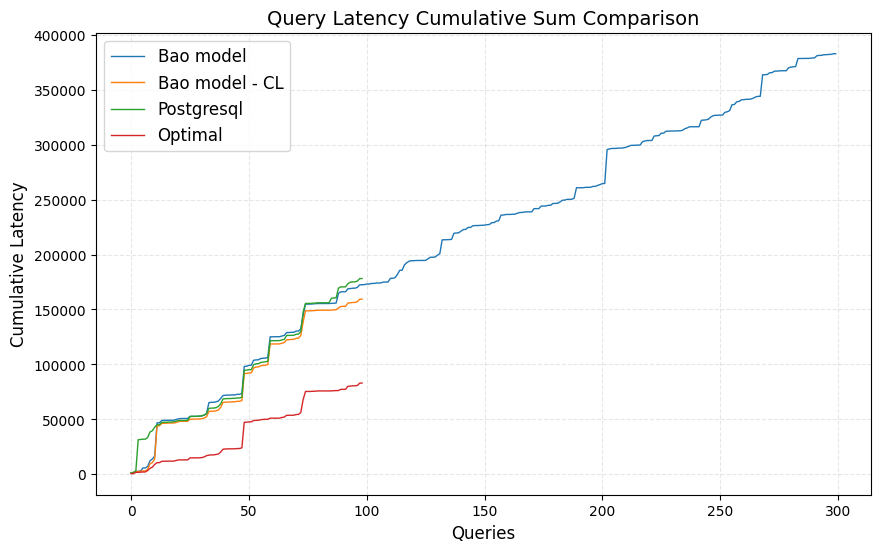

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd

ori_df = pd.read_csv("ori_res.csv")
cl_df = pd.read_csv("cl_res_counter100_buf2000_rs.csv")

# 1. 安全解析函数：如果元素是字符串就转成字典，如果已经是字典就直接用
def get_val(item, key):
    if isinstance(item, str):
        try:
            item = json.loads(item.replace("'", '"')) # 兼容单引号的 JSON 字符串
        except Exception:
            return 0
    return item.get(key, 0) if isinstance(item, dict) else 0

# 2. 提取数据（限制前 200 个，并安全获取延迟值）
ori_latencies     = ori_df["bao_latency"].iloc[:-1].fillna(0)
cl_latencies      = cl_df["bao_latency"].iloc[:-1].fillna(0)
default_latencies = cl_df["default_latency"].iloc[:-1].fillna(0)
optimal_latencies = cl_df["optimal_latency"].iloc[:-1].fillna(0)
# ori_latencies     = [get_val(item, "bao_latency") for item in ori_res_list_1[:3000]]
# cl_latencies     = [get_val(item, "bao_latency") for item in cl_res_list_1[:3000]]
# default_latencies = [get_val(item, "default_latency") for item in cl_res_list_1[:3000]]
# optimal_latencies = [get_val(item, "optimal_latency") for item in cl_res_list_1[:3000]]

# 3. 计算累计值 (使用 numpy 的 cumsum 函数)
ori_cum_sum = np.cumsum(ori_latencies[:300])
cl_cum_sum  = np.cumsum(cl_latencies[:300])
de_cum_sum  = np.cumsum(default_latencies[:300])
op_cum_sum  = np.cumsum(optimal_latencies[:300])
# 4. 绘制可视化曲线
plt.figure(figsize=(10, 6))

# 画出两条累加曲线
plt.plot(ori_cum_sum, label="Bao model", linewidth=1)
plt.plot(cl_cum_sum, label="Bao model - CL", linewidth=1)
plt.plot(de_cum_sum, label="Postgresql", linewidth=1)
plt.plot(op_cum_sum, label="Optimal", linewidth=1)

# 添加图表信息
plt.title("Query Latency Cumulative Sum Comparison", fontsize=14)
plt.xlabel("Queries", fontsize=12)
plt.ylabel("Cumulative Latency", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend(fontsize=12)

# 显示图表
plt.show()
